In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv('emails.csv',encoding='latin-1')

In [84]:
df

,text,spam
0,subject natur irresist corpor ident lt realli ...,1
1,subject stock trade gunsl fanni merril muzo co...,1
2,subject unbeliev new home made easi im want sh...,1
3,subject 4 color print special request addit in...,1
4,subject money get softwar cd softwar compat gr...,1
...,...,...
5723,subject research develop charg gpg forward shi...,0
5724,subject receipt visit jim thank invit visit ls...,0
5725,subject enron case studi updat wow day super t...,0
5726,subject interest david plea call shirley crens...,0


EDA

In [9]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [11]:
df.columns

Index(['text', 'spam'], dtype='object')

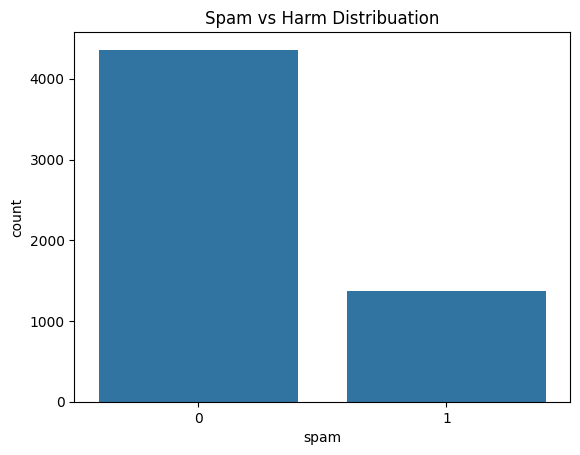

In [18]:
sns.countplot(data=df,x='spam')
plt.title('Spam vs Harm Distribuation')
plt.show()

In [19]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [22]:
df.value_counts

<bound method DataFrame.value_counts of                                                    text  spam
0     Subject: naturally irresistible your corporate...     1
1     Subject: the stock trading gunslinger  fanny i...     1
2     Subject: unbelievable new homes made easy  im ...     1
3     Subject: 4 color printing special  request add...     1
4     Subject: do not have money , get software cds ...     1
...                                                 ...   ...
5723  Subject: re : research and development charges...     0
5724  Subject: re : receipts from visit  jim ,  than...     0
5725  Subject: re : enron case study update  wow ! a...     0
5726  Subject: re : interest  david ,  please , call...     0
5727  Subject: news : aurora 5 . 2 update  aurora ve...     0

[5728 rows x 2 columns]>

Preprocessing

In [36]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [40]:
stop_words=set(stopwords.words('english'))
print(stop_words)

{"we'd", 'my', "wasn't", 'm', 'been', 'such', 'once', 'is', 'over', "they'd", "i'll", 'themselves', 'the', 'll', "should've", 'has', "they're", 'any', 'off', 'a', 'or', "shouldn't", 'just', 'where', 'we', 'while', 'in', 'ourselves', 'so', 'me', 'some', 'but', 'him', 'hers', 'didn', 'our', 'ours', 'will', 'from', 'her', "he'd", 'its', 't', 'about', 'each', 'being', 'i', 'yourself', 'are', "we'll", 'too', "aren't", 'both', 'that', 'aren', 'after', 'not', 'have', 'then', 'before', 'should', 'when', 'same', "it'll", 'own', "she'll", 'to', "that'll", 're', 'she', 'mustn', 'who', "don't", 'hadn', 'why', 'through', 'by', "he'll", 'couldn', "she's", 'y', 'they', 'herself', 'o', 'on', 'under', "hadn't", "weren't", 's', 'until', 'shan', "it's", 'few', 'above', "doesn't", 'hasn', 'was', 'haven', 'for', "you'll", 'against', 'can', 'with', "we're", "couldn't", 'won', 'myself', 'you', 'an', 'their', 'wouldn', 'because', "he's", "i'd", "needn't", "didn't", "they'll", 'these', 'were', 'doesn', "wouldn

In [39]:
ps=PorterStemmer()

In [76]:
def preprocessing(text):
    text=text.lower()
    text="".join(
        ch for ch in text if ch not in string.punctuation
    )
    words=text.split()
    words=[
        word for word in words if word not in stop_words
    ]
    
    words=[
        ps.stem(word) for word in words
    ]
    return " ".join(words)

In [82]:
df['text']=df['text'].apply(preprocessing)

In [83]:
df['text'].head()

0    subject natur irresist corpor ident lt realli ...
1    subject stock trade gunsl fanni merril muzo co...
2    subject unbeliev new home made easi im want sh...
3    subject 4 color print special request addit in...
4    subject money get softwar cd softwar compat gr...
Name: text, dtype: object

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [86]:
tf=TfidfVectorizer()

In [118]:
x=tf.fit_transform(df['text'])
y=df['spam']

TRAIN-TEST-SPLIT

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [144]:
models={
    'LogisticRegression':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'Naive_model':MultinomialNB(),
    'Tree-Model':DecisionTreeClassifier()
}
result=[]

In [145]:
for name,model in models.items():
    model.fit(X_train,y_train)
    y_prediction=model.predict(X_test)
    F1=f1_score(y_test,y_prediction)
    
    result.append(
        {
            'Model': name,
            'F1 Score': F1
        }
    )

In [146]:
result

[{'Model': 'LogisticRegression', 'F1 Score': 0.9498207885304659},
 {'Model': 'KNN', 'F1 Score': 0.9373881932021467},
 {'Model': 'Naive_model', 'F1 Score': 0.6818181818181818},
 {'Model': 'Tree-Model', 'F1 Score': 0.9116117850953206}]

SAVE THE BEST MODEL

In [148]:
import joblib
joblib.dump(models['LogisticRegression'],'best_model.pkl')
joblib.dump(tf,'tf.pkl')

['tf.pkl']

In [149]:
print(x.shape)


(5728, 29020)


In [152]:
print(len(tf.get_feature_names_out()))

29020
